In [5]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from armijo import armijo

In [2]:
def f(x):
    return .26 * (x[0]**2 + x[1]**2) - .46 * x[0] * x[1]

def grad_f(x):
    return np.array([.52 * x[0] - .46 * x[1], .52 * x[1] - .46 * x[0]])

In [ ]:
x = np.array([-4, -2])
iters = 0

locations = [x]

while iters < 100:
    x, _ = armijo(f, grad_f, x, 1e-4, 0.5, 1)
    locations.append(x)
    iters += 1

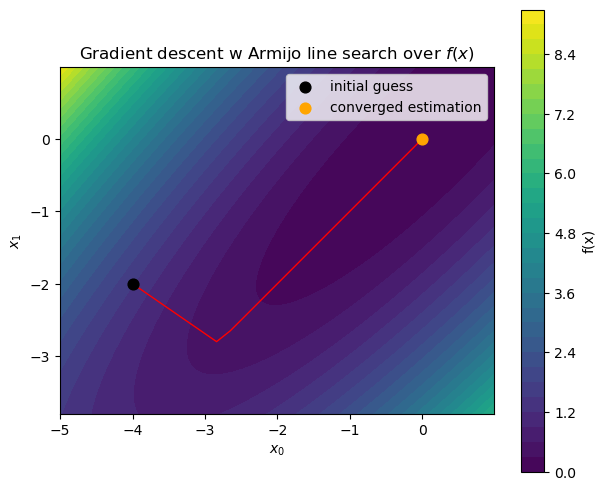

In [12]:
locs = np.array(locations)

# Grid for the contours, padded around the visited points
pad = 1.0
x_min, y_min = locs.min(axis=0) - pad
x_max, y_max = locs.max(axis=0) + pad
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))
zz = f([xx, yy])

fig, ax = plt.subplots(figsize=(7, 6))
cs = ax.contourf(xx, yy, zz, levels=30, cmap='viridis')
fig.colorbar(cs, ax=ax, label='f(x)')

# Path connecting successive iterates
ax.plot(locs[:, 0], locs[:, 1], '-', color='red', lw=1, zorder=2)

# Initial (black) and final (orange) points
ax.scatter(*locs[0],  color='black',  s=60, zorder=3, label='initial guess')
ax.scatter(*locs[-1], color='orange', s=60, zorder=3, label='converged estimation')

ax.set_xlabel('$x_0$')
ax.set_ylabel('$x_1$')
ax.set_title('Gradient descent w Armijo line search over $f(x)$')
ax.legend()
ax.set_aspect('equal')
plt.show()